# Kernel SVM

## Importing the libraries

In [ ]:
# Dataset link
# https://www.kaggle.com/datasets/akram24/social-network-ads


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [9]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].to_numpy()
y = dataset.iloc[:, -1].to_numpy()
dataset

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


## Splitting the dataset into the Training set and Test set

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


lr = LogisticRegression(random_state=0)
lr.fit(X_train_sc, y_train)

knn = KNeighborsClassifier()
knn.fit(X_train_sc, y_train)

svc = SVC(random_state=0)
svc.fit(X_train_sc, y_train)

nb = GaussianNB()
nb.fit(X_train, y_train)

dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=10, random_state=0)
rf.fit(X_train, y_train)



,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
from sklearn.metrics import confusion_matrix, roc_auc_score

cm = confusion_matrix(y_test, lr.predict(X_test_sc))
print("lr \n",cm)
cm = confusion_matrix(y_test, knn.predict(X_test_sc))
print("knn \n",cm)
cm = confusion_matrix(y_test, svc.predict(X_test_sc))
print("svc \n",cm)
cm = confusion_matrix(y_test, nb.predict(X_test))
print("nb \n",cm)
cm = confusion_matrix(y_test, dt.predict(X_test))
print("dt \n",cm)
cm = confusion_matrix(y_test, rf.predict(X_test))
print("rf \n",cm)


lr_result = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1])
print("lr AUC:", lr_result)

knn_result = roc_auc_score(y_test, knn.predict_proba(X_test_sc)[:, 1])
print("knn AUC:", knn_result)

svc_result = roc_auc_score(y_test, svc.decision_function(X_test_sc))
print("svc AUC:", svc_result)

nb_result = roc_auc_score(y_test, nb.predict_proba(X_test)[:, 1])
print("nb AUC:", nb_result)

dt_result = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])
print("dt AUC:", dt_result)

rf_result = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print("rf AUC:", rf_result)

lr 
 [[65  3]
 [ 8 24]]
knn 
 [[64  4]
 [ 3 29]]
svc 
 [[64  4]
 [ 3 29]]
nb 
 [[65  3]
 [ 7 25]]
dt 
 [[62  6]
 [ 4 28]]
rf 
 [[64  4]
 [ 3 29]]
lr AUC: 0.9540441176470588
knn AUC: 0.9630055147058824
svc AUC: 0.9646139705882353
nb AUC: 0.964154411764706
dt AUC: 0.8933823529411764
rf AUC: 0.9618566176470589


In [59]:
knn.predict_proba(X_test_sc)

array([[1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [0. , 1. ],
       [1. , 0. ],
       [0.2, 0.8],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [0.8, 0.2],
       [1. , 0. ],
       [0.4, 0.6],
       [0.8, 0.2],
       [1. , 0. ],
       [0.2, 0.8],
       [1. , 0. ],
       [1. , 0. ],
       [0.2, 0.8],
       [1. , 0. ],
       [0.2, 0.8],
       [1. , 0. ],
       [0.4, 0.6],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [0.8, 0.2],
       [0. , 1. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [0. , 1. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [0. , 1. ],
       [1. , 0. ],
       [0.8, 0.2],
       [0. , 1. ],
       [1. , 0. ],
       [0. , 1. ],
       [0. , 1. ],
       [1. , 0. ],
       [1. ,

C:\Users\alasr\AppData\Local\Temp\ipykernel_21960\3501760368.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_train[:,0][y_train == i], X_train[:,1][y_train == i], c=ListedColormap(["red", "blue"])(i), label=i)


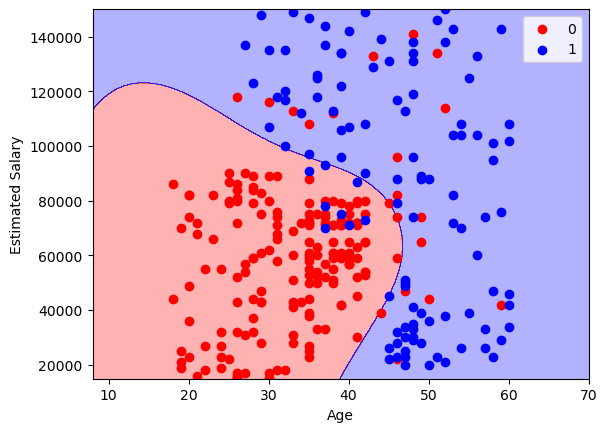

In [ ]:
from matplotlib.colors import ListedColormap
x1 = np.linspace(X_train[:, 0].min()-10, X_train[:, 0].max()+10, 1000)
x2 = np.linspace(X_train[:, 1].min()-100, X_train[:, 1].max()+100, 1000)


x1, x2 = np.meshgrid(x1, x2)

features = np.array([x1.ravel(), x2.ravel()]).T
y_pred = svc.predict(sc.transform(features)).reshape(x1.shape)



plt.contourf(x1, x2, y_pred, alpha=0.3 ,cmap=ListedColormap(["red", "blue"]))

for i in np.unique(y):
    plt.scatter(X_train[:,0][y_train == i], X_train[:,1][y_train == i], c=ListedColormap(["red", "blue"])(i), label=i)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()


C:\Users\alasr\AppData\Local\Temp\ipykernel_21960\1575445874.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_test[:,0][y_test == i], X_test[:,1][y_test == i], c=ListedColormap(["red", "blue"])(i), label=i)


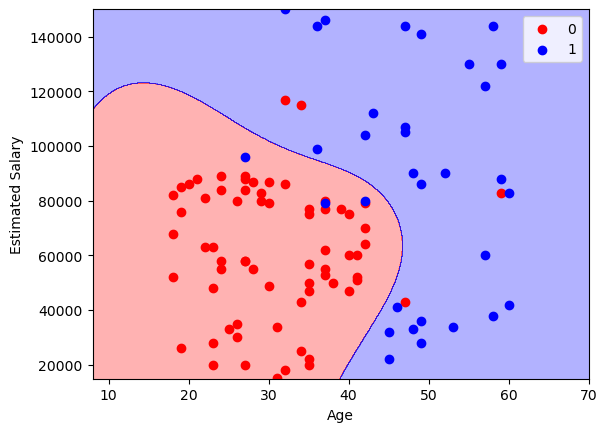

In [51]:
x1 = np.linspace(X_test[:, 0].min()-10, X_test[:, 0].max()+10, 1000)
x2 = np.linspace(X_test[:, 1].min()-100, X_test[:, 1].max()+100, 1000)


x1, x2 = np.meshgrid(x1, x2)

features = np.array([x1.ravel(), x2.ravel()]).T
y_pred = svc.predict(sc.transform(features)).reshape(x1.shape)



plt.contourf(x1, x2, y_pred, alpha=0.3 ,cmap=ListedColormap(["red", "blue"]))

for i in np.unique(y_test):
    plt.scatter(X_test[:,0][y_test == i], X_test[:,1][y_test == i], c=ListedColormap(["red", "blue"])(i), label=i)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()
